In [11]:
import numpy as np
from scipy.sparse import eye
from scipy.sparse.linalg import expm, expm_multiply, norm
from utils import *
import matplotlib.pyplot as plt

Consider QW on a 1D chain

In [81]:

T = 1
n_vals = np.arange(2, 9)
g = 1000
r = 1

penalty_free_error = []
thrift_error = []
for n in n_vals:

    print(f"n = {n}")

    # Ground truth
    A = np.zeros((n,n))
    for i in range(n-1):
        A[i,i+1] = 1
        A[i+1,i] = 1

    U_A = expm(-1j * T * A)

    # Hamiltonian embedding
    codewords = get_codewords_1d(n, encoding="one-hot", periodic=False)
    # bitstrings = get_bitstrings(n, 1, encoding="one-hot")
    J_even = np.zeros((n,n))
    J_odd = np.zeros((n,n))
    for i in np.arange(0, n-1, 2):
        J_even[i,i+1] = 1
    for i in np.arange(1, n-1, 2):
        J_odd[i,i+1] = 1
    J = J_even + J_odd

    print("-- One-hot w/o penalty --")
    # Penalty free one-hot embedding
    A_even = np.zeros((n,n))
    A_odd = np.zeros((n,n))
    for i in np.arange(0, n-1, 2):
        A_even[i,i+1] = 1
        A_even[i+1,i] = 1
    for i in np.arange(1, n-1, 2):
        A_odd[i,i+1] = 1
        A_odd[i+1,i] = 1

    A_even = csc_matrix(A_even)
    A_odd = csc_matrix(A_odd)
    U_one_hot_subspace = eye(n)
    for _ in range(r):
        U_one_hot_subspace = expm_multiply(-1j * (T/r) * A_even, U_one_hot_subspace)
        U_one_hot_subspace = expm_multiply(-1j * (T/r) * A_odd, U_one_hot_subspace)

    error = np.linalg.norm(U_A - U_one_hot_subspace, ord=2)
    print("Penalty-free error:", error)
    penalty_free_error.append(error)

    print("\n-- One-hot with penalty --")
    # One-hot with penalty
    # r_vals = np.arange(10, 100, 10)

    # leakage_error = []
    # trotter_error = []
    H_one_hot_pen = sum_J_xx(n, J) + g * (sum_h_z(n, np.ones(n)) - (n-2) * eye(2 ** n))
    U_one_hot_pen = expm(-1j * T * H_one_hot_pen)
    U_one_hot_pen_subspace = U_one_hot_pen[codewords][:,codewords]

    # # Leakage error
    print("Leakage error (no Trotter):", 1 - np.abs(np.sum(U_one_hot_pen_subspace @ np.conj(U_one_hot_pen_subspace.T))) / n)
    # print("Fidelity:", np.abs(np.sum(U_one_hot_pen_subspace @ np.conj(U_A.T)) / n))
    # error = np.linalg.norm(U_A - U_one_hot_pen_subspace, ord=2)
    # print("Effective Trotter error:", error)
    # print()
    # Thrift
    print("Thrift formula")
    H_1 = sum_J_xx(n, J)
    H_1_even = sum_J_xx(n, J_even)
    H_1_odd = sum_J_xx(n, J_odd)
    H_0 = (sum_h_z(n, np.ones(n)) - (n-2) * eye(2 ** n))

    alpha = 1 / g
    T_thrift = T * g
    U_one_hot_pen = eye(2 ** n)
    for _ in range(r):
        U_one_hot_pen = expm_multiply(-1j * (T_thrift / r) * (H_0 + alpha * H_1_even), U_one_hot_pen)
        U_one_hot_pen = expm_multiply(1j * (T_thrift / r) * (H_0), U_one_hot_pen)
        U_one_hot_pen = expm_multiply(-1j * (T_thrift / r) * (H_0 + alpha * H_1_odd), U_one_hot_pen)
    U_one_hot_pen_subspace = U_one_hot_pen[codewords][:,codewords]
    print("Leakage error:", 1 - np.abs(np.sum(U_one_hot_pen_subspace @ np.conj(U_one_hot_pen_subspace.T))) / n)
    # print("Fidelity:", np.abs(np.sum(U_one_hot_pen_subspace @ np.conj(U_A.T)) / n))
    error = np.linalg.norm(U_A - U_one_hot_pen_subspace, ord=2)
    print("Effective Trotter error:", error)
    thrift_error.append(error)

    # leakage_error.append(1 - np.abs(np.sum(U_one_hot_pen_subspace @ np.conj(U_one_hot_pen_subspace.T))) / n)
    # trotter_error.append(error)
    print()

# r_vals = np.arange(3, 20)
# trot_error_thrift = []
# for r in r_vals:
#     U_one_hot_pen = eye(2 ** n)
#     for _ in range(r):
#         U_one_hot_pen = expm_multiply(-1j * (T_thrift / r) * (H_0 + alpha * H_1_even), U_one_hot_pen)
#         U_one_hot_pen = expm_multiply(1j * (T_thrift / r) * (H_0), U_one_hot_pen)
#         U_one_hot_pen = expm_multiply(-1j * (T_thrift / r) * (H_0 + alpha * H_1_odd), U_one_hot_pen)
#         # U_one_hot_pen = expm_multiply(1j * (T_thrift / r) * (H_0), U_one_hot_pen)
#         # U_one_hot_pen = expm_multiply(-1j * (T_thrift / r) * H_0, U_one_hot_pen)

#     trot_error_thrift.append(norm(U_one_hot_pen - expm(-1j * T * (g * H_0 + H_1)), ord=2))

n = 2
-- One-hot w/o penalty --
Penalty-free error: 1.1102230246251565e-16

-- One-hot with penalty --
Leakage error (no Trotter): 4.107825191113079e-15
Thrift formula
Leakage error: -9.769962616701378e-15
Effective Trotter error: 5.185714680139075e-15

n = 3
-- One-hot w/o penalty --
Penalty-free error: 0.46960065324888084

-- One-hot with penalty --
Leakage error (no Trotter): 6.53090975744064e-08
Thrift formula
Leakage error: 2.2197899174347668e-07
Effective Trotter error: 0.46982094907641836

n = 4
-- One-hot w/o penalty --
Penalty-free error: 0.43464475124185104

-- One-hot with penalty --
Leakage error (no Trotter): 3.2243184944213965e-07
Thrift formula
Leakage error: 4.410688119182993e-07
Effective Trotter error: 0.4350818105227782

n = 5
-- One-hot w/o penalty --
Penalty-free error: 0.6140413619005599

-- One-hot with penalty --
Leakage error (no Trotter): 4.7409479486670847e-07
Thrift formula
Leakage error: 7.385616467292522e-07
Effective Trotter error: 0.6146272364604163

n =

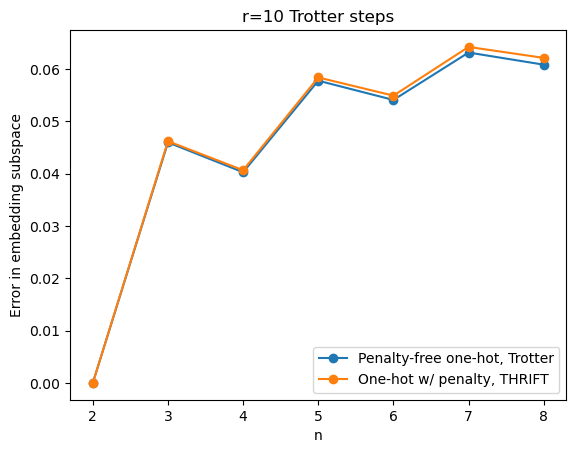

In [80]:
plt.plot(n_vals, penalty_free_error, '-o', label="Penalty-free one-hot, Trotter")
plt.plot(n_vals, thrift_error, '-o', label="One-hot w/ penalty, THRIFT")
plt.xlabel("n")
plt.ylabel("Error in embedding subspace")
plt.title(f"r={r} Trotter steps")
plt.legend()
plt.show()

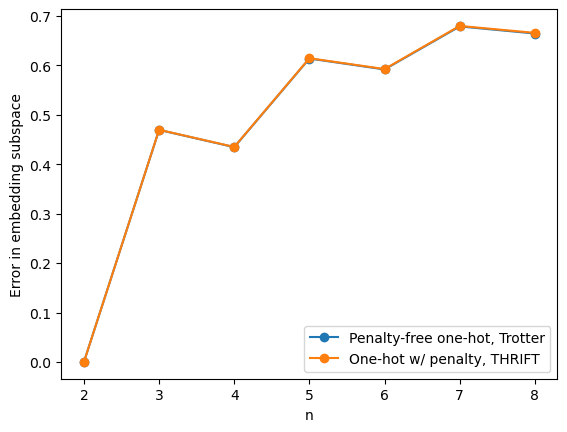

In [84]:
plt.plot(n_vals, penalty_free_error, '-o', label="Penalty-free one-hot, Trotter")
plt.plot(n_vals, thrift_error, '-o', label="One-hot w/ penalty, THRIFT")
plt.xlabel("n")
plt.ylabel("Error in embedding subspace")
# plt.title(f"r={r} Trotter steps")
plt.legend()
plt.show()

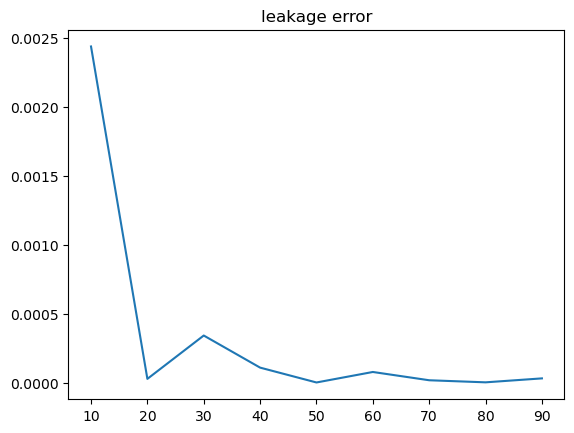

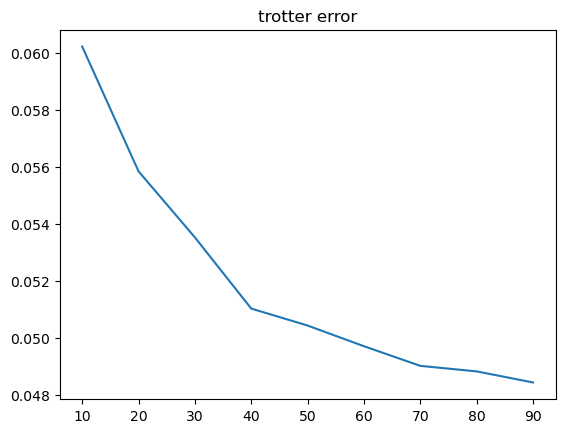

In [69]:
plt.plot(g_vals, leakage_error)
plt.title("leakage error")
plt.show()
plt.plot(g_vals, trotter_error)
plt.title("trotter error")
plt.show()

In [16]:
np.polyfit(np.log(r_vals), np.log(trot_error_thrift), deg=1)

array([-0.99807804, -0.77741646])

In [65]:
T = 1
g = 10

H_one_hot_pen = sum_J_xx(n, J) + g * (sum_h_z(n, np.ones(n)) - (n-2) * eye(2 ** n))
U_one_hot_pen = expm(-1j * T * H_one_hot_pen)
U_one_hot_pen_subspace = U_one_hot_pen[codewords][:,codewords]

# Leakage error
print("Average leakage error:", 1 - np.abs(np.sum(U_one_hot_pen_subspace @ np.conj(U_one_hot_pen_subspace.T))) / n)

num_samples = 10000
leakage_error = []
for _ in range(num_samples):
    psi_0 = np.zeros(2**n, dtype=np.complex128)
    psi_0[codewords] = np.random.rand(n) + 1j * np.random.rand(n)
    psi_0 /= np.linalg.norm(psi_0)
    psi = expm_multiply(-1j * T * H_one_hot_pen, psi_0)
    leakage_error.append(1-np.sum(np.abs(psi[codewords])**2))
print(np.average(leakage_error))

Average leakage error: 0.0021403349737062483
0.0018009530567586723
